Importing Dependencies

In [225]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

user dataset

In [226]:
## Load the users dataset
users=pd.read_csv("Users.csv")

In [227]:
## number of rows and columns in the DataFrame
users.shape

(278858, 3)

In [228]:
## first 5 rows of DataFrame
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [229]:
## getting some informations about the dataset
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  object 
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 6.4+ MB


In [230]:
## statistical Measures of the dataset
users.describe()

,User-ID,Age
count,278858.00000,168096.000000
mean,139429.50000,34.751434
std,80499.51502,14.428097
min,1.00000,0.000000
25%,69715.25000,24.000000
50%,139429.50000,32.000000
75%,209143.75000,44.000000
max,278858.00000,244.000000


In [231]:
##check duplicates
users.duplicated().sum()

np.int64(0)

No duplicates present in users dataset

In [232]:
##check missing values
users.isnull().sum()

,0
User-ID,0
Location,0
Age,110762


Age column contain null value

In [233]:
users['Age'] = users['Age'].fillna(users['Age'].median())

In [234]:
users.isnull().sum()

,0
User-ID,0
Location,0
Age,0


In [235]:
users['Age'] = users['Age'].astype(int)


In [236]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   User-ID   278858 non-null  int64 
 1   Location  278858 non-null  object
 2   Age       278858 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 6.4+ MB


In [237]:
## unique values present in age
users['Age'].unique()

array([ 32,  18,  17,  61,  26,  14,  25,  19,  46,  55,  24,  20,  34,
        23,  51,  31,  21,  44,  30,  57,  43,  37,  41,  54,  42,  50,
        39,  53,  47,  36,  28,  35,  13,  58,  49,  38,  45,  62,  63,
        27,  33,  29,  66,  40,  15,  60,   0,  79,  22,  16,  65,  59,
        48,  72,  56,  67,   1,  80,  52,  69,  71,  73,  78,   9,  64,
       103, 104,  12,  74,  75, 231,   3,  76,  83,  68, 119,  11,  77,
         2,  70,  93,   8,   7,   4,  81, 114, 230, 239,  10,   5, 148,
       151,   6, 101, 201,  96,  84,  82,  90, 123, 244, 133,  91, 128,
        94,  85, 141, 110,  97, 219,  86, 124,  92, 175, 172, 209, 212,
       237,  87, 162, 100, 156, 136,  95,  89, 106,  99, 108, 210,  88,
       199, 147, 168, 132, 159, 186, 152, 102, 116, 200, 115, 226, 137,
       207, 229, 138, 109, 105, 228, 183, 204,  98, 223, 113, 208, 107,
       157, 111, 146, 118, 220, 143, 140, 189, 127])

In [238]:
users.loc[(users['Age'] < 5) | (users['Age'] > 90), 'Age'] = users['Age'].median()

In [239]:
users['Age'].unique()

array([32, 18, 17, 61, 26, 14, 25, 19, 46, 55, 24, 20, 34, 23, 51, 31, 21,
       44, 30, 57, 43, 37, 41, 54, 42, 50, 39, 53, 47, 36, 28, 35, 13, 58,
       49, 38, 45, 62, 63, 27, 33, 29, 66, 40, 15, 60, 79, 22, 16, 65, 59,
       48, 72, 56, 67, 80, 52, 69, 71, 73, 78,  9, 64, 12, 74, 75, 76, 83,
       68, 11, 77, 70,  8,  7, 81, 10,  5,  6, 84, 82, 90, 85, 86, 87, 89,
       88])

<Axes: >

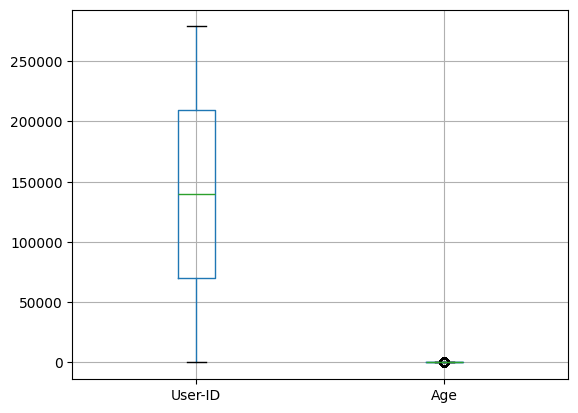

In [240]:
## check outliers
users.boxplot()

In [241]:
def outlier_cappping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[column]=df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in users.select_dtypes(['int','float']).columns:
    outlier_cappping(users,col)

<Axes: >

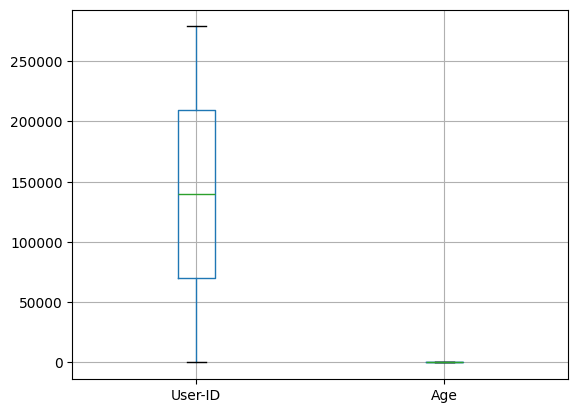

In [242]:
users.boxplot()

Age Distribution

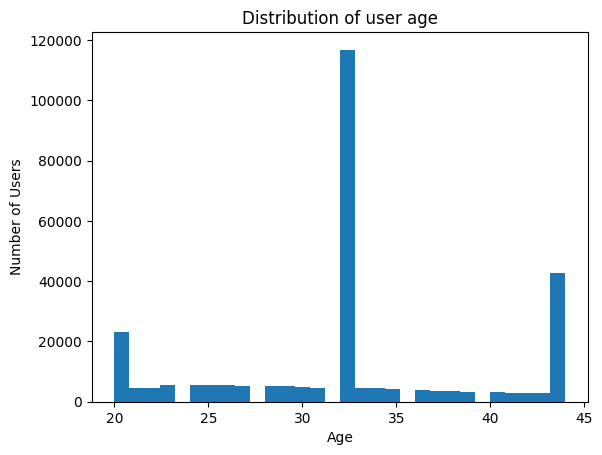

In [243]:
plt.hist(users['Age'],bins=30)
plt.title("Distribution of user age")
plt.xlabel("Age")
plt.ylabel("Number of Users")
plt.show()

From this graph we can say that most users are between 30-35 age group

rating dataset

In [244]:
## load rating dataset
ratings = pd.read_csv("Ratings.csv")

In [245]:
## number of rows and columns in the DataFrame
ratings.shape

(1149780, 3)

In [246]:
## frist 5 rows of DataFrame
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [247]:
## some information about the DataFeame
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2   Book-Rating  1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB


In [248]:
## check duplicates
ratings.duplicated().sum()

np.int64(0)

No duplicate values present in ratings dataset

In [249]:
## check null values
ratings.isnull().sum()

,0
User-ID,0
ISBN,0
Book-Rating,0


There is no  null value in rating dataset

<Axes: >

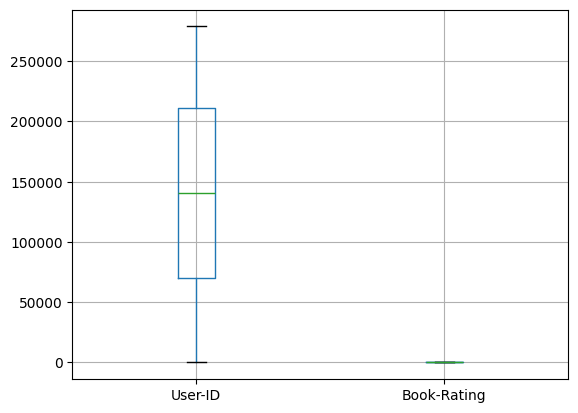

In [250]:
## chech outliers
ratings.boxplot()

No outliers present

In [251]:
## unique values present in ratings dataset
ratings['Book-Rating'].unique()

array([ 0,  5,  3,  6,  8,  7, 10,  9,  4,  1,  2])

In [252]:
## Rating Distribution
rating_counts = ratings['Book-Rating'].value_counts().sort_index()
rating_counts

,count
Book-Rating,
0,716109
1,1770
2,2759
3,5996
4,8904
5,50974
6,36924
7,76457
8,103736


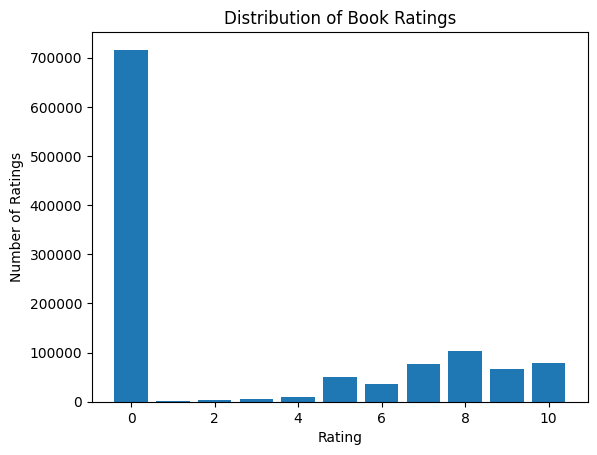

In [253]:
## Bar plot
plt.bar(rating_counts.index, rating_counts.values)
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.title("Distribution of Book Ratings")
plt.show()

Books dataset

In [254]:
## load the books dataset
books=pd.read_csv("Books.csv")


In [255]:
## number of rows and columns in the DataFrame
books.shape

(271360, 8)

In [256]:
## first 5 rows in the DataFrame
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [257]:
## some information about the dataset
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB


In [258]:
## check duplicates
books.duplicated().sum()

np.int64(0)

No duplicate value present in books dataset

In [259]:
## check null values
books.isnull().sum()

,0
ISBN,0
Book-Title,0
Book-Author,2
Year-Of-Publication,0
Publisher,2
Image-URL-S,0
Image-URL-M,0
Image-URL-L,3


In [260]:
books['Book-Author']=books['Book-Author'].fillna("unknown")

In [261]:
books['Publisher']=books['Publisher'].fillna("unknown")

In [262]:
books['Image-URL-L']=books['Image-URL-L'].fillna("Image-URL-M")

In [263]:
books.isnull().sum()

,0
ISBN,0
Book-Title,0
Book-Author,0
Year-Of-Publication,0
Publisher,0
Image-URL-S,0
Image-URL-M,0
Image-URL-L,0


In [264]:
books['Year-Of-Publication'].unique()

array([2002, 2001, 1991, 1999, 2000, 1993, 1996, 1988, 2004, 1998, 1994,
       2003, 1997, 1983, 1979, 1995, 1982, 1985, 1992, 1986, 1978, 1980,
       1952, 1987, 1990, 1981, 1989, 1984, 0, 1968, 1961, 1958, 1974,
       1976, 1971, 1977, 1975, 1965, 1941, 1970, 1962, 1973, 1972, 1960,
       1966, 1920, 1956, 1959, 1953, 1951, 1942, 1963, 1964, 1969, 1954,
       1950, 1967, 2005, 1957, 1940, 1937, 1955, 1946, 1936, 1930, 2011,
       1925, 1948, 1943, 1947, 1945, 1923, 2020, 1939, 1926, 1938, 2030,
       1911, 1904, 1949, 1932, 1928, 1929, 1927, 1931, 1914, 2050, 1934,
       1910, 1933, 1902, 1924, 1921, 1900, 2038, 2026, 1944, 1917, 1901,
       2010, 1908, 1906, 1935, 1806, 2021, '2000', '1995', '1999', '2004',
       '2003', '1990', '1994', '1986', '1989', '2002', '1981', '1993',
       '1983', '1982', '1976', '1991', '1977', '1998', '1992', '1996',
       '0', '1997', '2001', '1974', '1968', '1987', '1984', '1988',
       '1963', '1956', '1970', '1985', '1978', '1973', '1980'

As you can see in Year-of-Publication columns some strings are present. so we have to convert that into integer form

In [265]:
books['Year-Of-Publication'] = pd.to_numeric(books['Year-Of-Publication'], errors='coerce')

In [266]:
books['Year-Of-Publication'].fillna(books['Year-Of-Publication'].median(), inplace=True)

In [267]:
books['Year-Of-Publication'] = books['Year-Of-Publication'].astype(int)

In [268]:
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271360 non-null  object
 3   Year-Of-Publication  271360 non-null  int64 
 4   Publisher            271360 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271360 non-null  object
dtypes: int64(1), object(7)
memory usage: 16.6+ MB


In [269]:
# Count books per year
books_per_year = books['Year-Of-Publication'].value_counts().sort_index()
books_per_year

,count
Year-Of-Publication,
0,4618
1376,1
1378,1
1806,1
1897,1
...,...
2026,1
2030,7
2037,1


In [270]:
# Remove unrealistic years
books = books[(books['Year-Of-Publication'] > 1900) &
              (books['Year-Of-Publication'] <= 2025)]

In [271]:
books_per_year = books['Year-Of-Publication'].value_counts().sort_index()
books_per_year

,count
Year-Of-Publication,
1901,7
1902,2
1904,1
1906,1
1908,1
...,...
2011,2
2012,1
2020,3


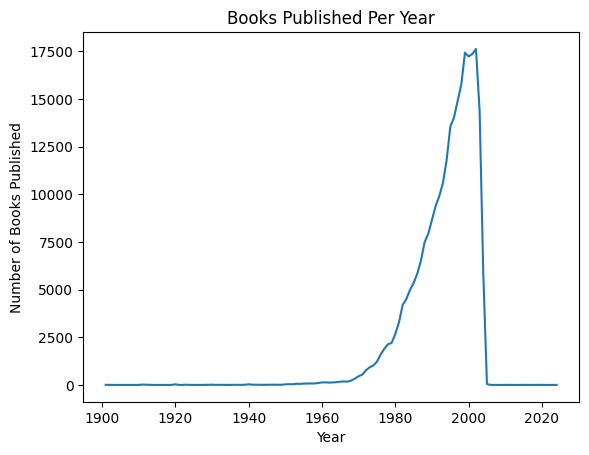

In [272]:
plt.figure()
plt.plot(books_per_year.index, books_per_year.values)
plt.xlabel("Year")
plt.ylabel("Number of Books Published")
plt.title("Books Published Per Year")
plt.show()

Merge the DataSets

In [273]:
ratings_users=pd.merge(ratings,users,on='User-ID',how='inner')
ratings_users

,User-ID,ISBN,Book-Rating,Location,Age
0,276725,034545104X,0,"tyler, texas, usa",32.0
1,276726,0155061224,5,"seattle, washington, usa",32.0
2,276727,0446520802,0,"h, new south wales, australia",20.0
3,276729,052165615X,3,"rijeka, n/a, croatia",20.0
4,276729,0521795028,6,"rijeka, n/a, croatia",20.0
...,...,...,...,...,...
1149775,276704,1563526298,9,"cedar park, texas, usa",32.0
1149776,276706,0679447156,0,"quebec, quebec, canada",20.0
1149777,276709,0515107662,10,"mannington, west virginia, usa",38.0
1149778,276721,0590442449,10,"providence, rhode island, usa",20.0


In [274]:
final_df=pd.merge(ratings_users,books,on='ISBN',how='inner')
final_df

,User-ID,ISBN,Book-Rating,Location,Age,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,276725,034545104X,0,"tyler, texas, usa",32.0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...
1,276726,0155061224,5,"seattle, washington, usa",32.0,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...
2,276727,0446520802,0,"h, new south wales, australia",20.0,The Notebook,Nicholas Sparks,1996,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...
3,276729,052165615X,3,"rijeka, n/a, croatia",20.0,Help!: Level 1,Philip Prowse,1999,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...
4,276729,0521795028,6,"rijeka, n/a, croatia",20.0,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...
...,...,...,...,...,...,...,...,...,...,...,...,...
1017061,276704,0876044011,0,"cedar park, texas, usa",32.0,Edgar Cayce on the Akashic Records: The Book o...,Kevin J. Todeschi,1998,A.R.E. Press (Association of Research &amp; Enlig,http://images.amazon.com/images/P/0876044011.0...,http://images.amazon.com/images/P/0876044011.0...,http://images.amazon.com/images/P/0876044011.0...
1017062,276704,1563526298,9,"cedar park, texas, usa",32.0,Get Clark Smart : The Ultimate Guide for the S...,Clark Howard,2000,Longstreet Press,http://images.amazon.com/images/P/1563526298.0...,http://images.amazon.com/images/P/1563526298.0...,http://images.amazon.com/images/P/1563526298.0...
1017063,276706,0679447156,0,"quebec, quebec, canada",20.0,Eight Weeks to Optimum Health: A Proven Progra...,Andrew Weil,1997,Alfred A. Knopf,http://images.amazon.com/images/P/0679447156.0...,http://images.amazon.com/images/P/0679447156.0...,http://images.amazon.com/images/P/0679447156.0...
1017064,276709,0515107662,10,"mannington, west virginia, usa",38.0,The Sherbrooke Bride (Bride Trilogy (Paperback)),Catherine Coulter,1996,Jove Books,http://images.amazon.com/images/P/0515107662.0...,http://images.amazon.com/images/P/0515107662.0...,http://images.amazon.com/images/P/0515107662.0...


In [275]:
final_df.shape

(1017066, 12)

In [276]:
## Top rated books
final_df.groupby('Book-Title')['Book-Rating'].mean().sort_values(ascending=False).head(10)

,Book-Rating
Book-Title,
touch the flame,10.0
Geneva's Hope,10.0
Charakterhunde.,10.0
Sourcery (Discworld Novels (Audio)),10.0
Sourcery,10.0
Source Readings in Music History,10.0
Charismatic Capitalism: Direct Selling Organizations in America,10.0
fÃ?Â¼nfter sein,10.0
fom winde ferfeelt ( vom winde verfehlt). welt-strolch macht links-shreibreform.,10.0


In [277]:
## Average rating per book
book_avg_rating = ratings.groupby('ISBN')['Book-Rating'].mean().reset_index()
book_avg_rating.rename(columns={'Book-Rating':'Avg_Rating'}, inplace=True)

final_df = final_df.merge(book_avg_rating, on='ISBN')


In [278]:
final_df

,User-ID,ISBN,Book-Rating,Location,Age,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L,Avg_Rating
0,276725,034545104X,0,"tyler, texas, usa",32.0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,2.933333
1,276726,0155061224,5,"seattle, washington, usa",32.0,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,2.500000
2,276727,0446520802,0,"h, new south wales, australia",20.0,The Notebook,Nicholas Sparks,1996,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,4.060345
3,276729,052165615X,3,"rijeka, n/a, croatia",20.0,Help!: Level 1,Philip Prowse,1999,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,3.000000
4,276729,0521795028,6,"rijeka, n/a, croatia",20.0,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,6.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017061,276704,0876044011,0,"cedar park, texas, usa",32.0,Edgar Cayce on the Akashic Records: The Book o...,Kevin J. Todeschi,1998,A.R.E. Press (Association of Research &amp; Enlig,http://images.amazon.com/images/P/0876044011.0...,http://images.amazon.com/images/P/0876044011.0...,http://images.amazon.com/images/P/0876044011.0...,0.000000
1017062,276704,1563526298,9,"cedar park, texas, usa",32.0,Get Clark Smart : The Ultimate Guide for the S...,Clark Howard,2000,Longstreet Press,http://images.amazon.com/images/P/1563526298.0...,http://images.amazon.com/images/P/1563526298.0...,http://images.amazon.com/images/P/1563526298.0...,7.000000
1017063,276706,0679447156,0,"quebec, quebec, canada",20.0,Eight Weeks to Optimum Health: A Proven Progra...,Andrew Weil,1997,Alfred A. Knopf,http://images.amazon.com/images/P/0679447156.0...,http://images.amazon.com/images/P/0679447156.0...,http://images.amazon.com/images/P/0679447156.0...,2.925000
1017064,276709,0515107662,10,"mannington, west virginia, usa",38.0,The Sherbrooke Bride (Bride Trilogy (Paperback)),Catherine Coulter,1996,Jove Books,http://images.amazon.com/images/P/0515107662.0...,http://images.amazon.com/images/P/0515107662.0...,http://images.amazon.com/images/P/0515107662.0...,3.454545


<Axes: xlabel='Publisher'>

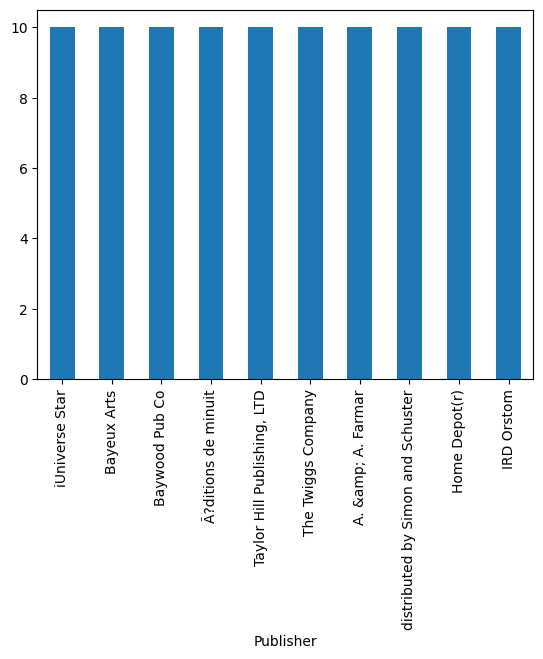

In [279]:
## top publishers with highesst rating
final_df.groupby('Publisher')['Book-Rating'].mean().sort_values(ascending=False).head(10).plot(kind='bar')


<Axes: xlabel='Year-Of-Publication', ylabel='Book-Rating'>

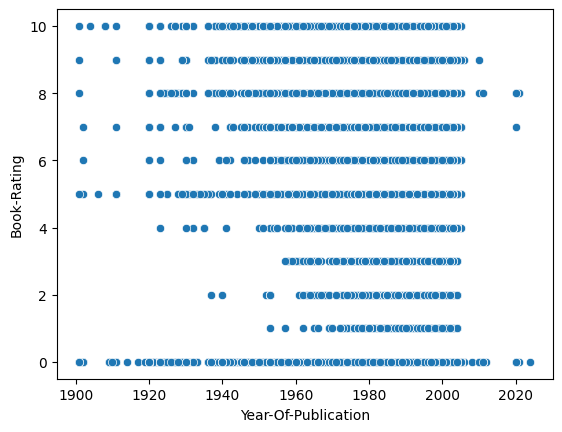

In [280]:
#Year of Publication vs Rating
sns.scatterplot(x='Year-Of-Publication', y='Book-Rating', data=final_df)

There is no clear correlation between publication year and rating, indicating that both old and new books receive comparable user appreciation

In [281]:
## Correlation Analysis
final_df[['Age','Book-Rating','Year-Of-Publication']].corr()

,Age,Book-Rating,Year-Of-Publication
Age,1.000000,-0.025592,-0.008959
Book-Rating,-0.025592,1.000000,0.038526
Year-Of-Publication,-0.008959,0.038526,1.000000


<Axes: >

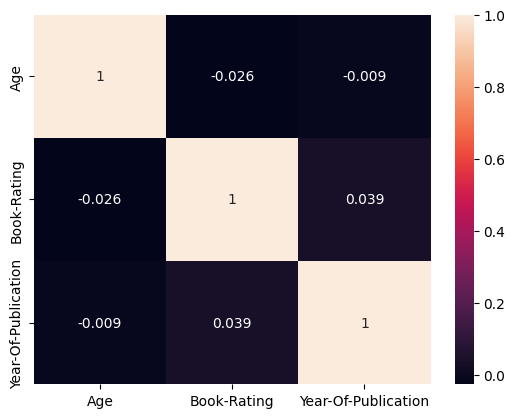

In [282]:
sns.heatmap(final_df[['Age','Book-Rating','Year-Of-Publication']].corr(),annot=True)

Weak correlation between age and rating indicates that rating preference is not strongly age dependent

In [283]:
# keeping only explicit ratings
final_df = final_df[final_df['Book-Rating'] > 0]
print("Explict Data Shape: ", final_df.shape)

Explict Data Shape:  (378031, 13)


In [284]:
final_df

,User-ID,ISBN,Book-Rating,Location,Age,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L,Avg_Rating
1,276726,0155061224,5,"seattle, washington, usa",32.0,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,2.500000
3,276729,052165615X,3,"rijeka, n/a, croatia",20.0,Help!: Level 1,Philip Prowse,1999,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,3.000000
4,276729,0521795028,6,"rijeka, n/a, croatia",20.0,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,6.000000
6,276744,038550120X,7,"torrance, california, usa",32.0,A Painted House,JOHN GRISHAM,2001,Doubleday,http://images.amazon.com/images/P/038550120X.0...,http://images.amazon.com/images/P/038550120X.0...,http://images.amazon.com/images/P/038550120X.0...,3.336957
13,276747,0060517794,9,"iowa city, iowa, usa",25.0,Little Altars Everywhere,Rebecca Wells,2003,HarperTorch,http://images.amazon.com/images/P/0060517794.0...,http://images.amazon.com/images/P/0060517794.0...,http://images.amazon.com/images/P/0060517794.0...,3.636364
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017058,276704,0743211383,7,"cedar park, texas, usa",32.0,Dreamcatcher,Stephen King,2001,Scribner,http://images.amazon.com/images/P/0743211383.0...,http://images.amazon.com/images/P/0743211383.0...,http://images.amazon.com/images/P/0743211383.0...,3.710280
1017060,276704,0806917695,5,"cedar park, texas, usa",32.0,Perplexing Lateral Thinking Puzzles: Scholasti...,Paul Sloane,1997,Sterling Publishing,http://images.amazon.com/images/P/0806917695.0...,http://images.amazon.com/images/P/0806917695.0...,http://images.amazon.com/images/P/0806917695.0...,5.000000
1017062,276704,1563526298,9,"cedar park, texas, usa",32.0,Get Clark Smart : The Ultimate Guide for the S...,Clark Howard,2000,Longstreet Press,http://images.amazon.com/images/P/1563526298.0...,http://images.amazon.com/images/P/1563526298.0...,http://images.amazon.com/images/P/1563526298.0...,7.000000
1017064,276709,0515107662,10,"mannington, west virginia, usa",38.0,The Sherbrooke Bride (Bride Trilogy (Paperback)),Catherine Coulter,1996,Jove Books,http://images.amazon.com/images/P/0515107662.0...,http://images.amazon.com/images/P/0515107662.0...,http://images.amazon.com/images/P/0515107662.0...,3.454545


In [285]:
# keeping only explicit ratings
final_df = final_df[final_df['Book-Rating'] > 0]
print("Explict Data Shape: ", final_df.shape)

Explict Data Shape:  (378031, 13)


In [286]:
user_counts = final_df['User-ID'].value_counts()
active_users = user_counts[user_counts >= 50].index

final_df = final_df[final_df['User-ID'].isin(active_users)]


In [287]:
book_counts = final_df['Book-Title'].value_counts()
popular_books = book_counts[book_counts >= 50].index

final_df = final_df[final_df['Book-Title'].isin(popular_books)]


In [288]:
print("Users:", final_df['User-ID'].nunique())
print("Books:", final_df['Book-Title'].nunique())
print("Total ratings:", final_df.shape)


Users: 948
Books: 64
Total ratings: (4338, 13)


In [289]:
final_df

,User-ID,ISBN,Book-Rating,Location,Age,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L,Avg_Rating
1176,277427,0316776963,8,"gilbert, arizona, usa",44.0,Me Talk Pretty One Day,David Sedaris,2001,Back Bay Books,http://images.amazon.com/images/P/0316776963.0...,http://images.amazon.com/images/P/0316776963.0...,http://images.amazon.com/images/P/0316776963.0...,3.691176
1231,277427,0385424736,9,"gilbert, arizona, usa",44.0,The Rainmaker,John Grisham,1995,Doubleday Books,http://images.amazon.com/images/P/0385424736.0...,http://images.amazon.com/images/P/0385424736.0...,http://images.amazon.com/images/P/0385424736.0...,3.860000
1237,277427,0385504209,8,"gilbert, arizona, usa",44.0,The Da Vinci Code,Dan Brown,2003,Doubleday,http://images.amazon.com/images/P/0385504209.0...,http://images.amazon.com/images/P/0385504209.0...,http://images.amazon.com/images/P/0385504209.0...,4.652322
1254,277427,0399501487,9,"gilbert, arizona, usa",44.0,Lord of the Flies,William Gerald Golding,1959,Perigee Trade,http://images.amazon.com/images/P/0399501487.0...,http://images.amazon.com/images/P/0399501487.0...,http://images.amazon.com/images/P/0399501487.0...,3.672340
1300,277427,0440224764,7,"gilbert, arizona, usa",44.0,The Partner,John Grisham,1998,Dell Publishing Company,http://images.amazon.com/images/P/0440224764.0...,http://images.amazon.com/images/P/0440224764.0...,http://images.amazon.com/images/P/0440224764.0...,3.160458
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1015286,275970,1586210661,9,"pittsburgh, pennsylvania, usa",44.0,Me Talk Pretty One Day,David Sedaris,2001,Time Warner Audio Major,http://images.amazon.com/images/P/1586210661.0...,http://images.amazon.com/images/P/1586210661.0...,http://images.amazon.com/images/P/1586210661.0...,9.000000
1016783,276680,0316666343,7,"hopewell junction, new york, usa",44.0,The Lovely Bones: A Novel,Alice Sebold,2002,"Little, Brown",http://images.amazon.com/images/P/0316666343.0...,http://images.amazon.com/images/P/0316666343.0...,http://images.amazon.com/images/P/0316666343.0...,4.468726
1016806,276680,0375727345,8,"hopewell junction, new york, usa",44.0,House of Sand and Fog,Andre Dubus III,2000,Vintage Books,http://images.amazon.com/images/P/0375727345.0...,http://images.amazon.com/images/P/0375727345.0...,http://images.amazon.com/images/P/0375727345.0...,3.039855
1016820,276680,0385504209,8,"hopewell junction, new york, usa",44.0,The Da Vinci Code,Dan Brown,2003,Doubleday,http://images.amazon.com/images/P/0385504209.0...,http://images.amazon.com/images/P/0385504209.0...,http://images.amazon.com/images/P/0385504209.0...,4.652322


In [290]:
user_item_matrix = final_df.pivot_table(
    index='User-ID',
    columns='Book-Title',
    values='Book-Rating'
)
user_item_matrix

Book-Title,1st to Die: A Novel,2nd Chance,A Painted House,A Time to Kill,Angels &amp; Demons,Bridget Jones's Diary,Divine Secrets of the Ya-Ya Sisterhood: A Novel,Dreamcatcher,Fahrenheit 451,Girl with a Pearl Earring,...,The Street Lawyer,The Summons,The Testament,"The Two Towers (The Lord of the Rings, Part 2)","The Vampire Lestat (Vampire Chronicles, Book II)",To Kill a Mockingbird,"Tuesdays with Morrie: An Old Man, a Young Man, and Life's Greatest Lesson",Where the Heart Is (Oprah's Book Club (Paperback)),Wicked: The Life and Times of the Wicked Witch of the West,Wild Animus
User-ID,,,,,,,,,,,,,,,,,,,,,
254,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
638,NaN,9.0,NaN,9.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,10.0,NaN,NaN,NaN,NaN,NaN,NaN
1424,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1733,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2033,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275970,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
276680,NaN,NaN,NaN,NaN,6.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
277427,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [291]:
user_item_matrix.fillna(0, inplace=True)

print(user_item_matrix.shape)


(948, 64)


In [292]:
user_item_matrix

Book-Title,1st to Die: A Novel,2nd Chance,A Painted House,A Time to Kill,Angels &amp; Demons,Bridget Jones's Diary,Divine Secrets of the Ya-Ya Sisterhood: A Novel,Dreamcatcher,Fahrenheit 451,Girl with a Pearl Earring,...,The Street Lawyer,The Summons,The Testament,"The Two Towers (The Lord of the Rings, Part 2)","The Vampire Lestat (Vampire Chronicles, Book II)",To Kill a Mockingbird,"Tuesdays with Morrie: An Old Man, a Young Man, and Life's Greatest Lesson",Where the Heart Is (Oprah's Book Club (Paperback)),Wicked: The Life and Times of the Wicked Witch of the West,Wild Animus
User-ID,,,,,,,,,,,,,,,,,,,,,
254,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
638,0.0,9.0,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0
1424,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1733,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2033,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275970,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
276680,0.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
277427,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [293]:

sparsity = 1 - (np.count_nonzero(user_item_matrix) / user_item_matrix.size)
print("Sparsity:", sparsity)


Sparsity: 0.9299841772151899


**USER-BASED CF**

In [294]:
## Normalizing the data
user_item_norm = user_item_matrix.subtract(
    user_item_matrix.mean(axis=1), axis=0
).fillna(0)
user_item_norm

Book-Title,1st to Die: A Novel,2nd Chance,A Painted House,A Time to Kill,Angels &amp; Demons,Bridget Jones's Diary,Divine Secrets of the Ya-Ya Sisterhood: A Novel,Dreamcatcher,Fahrenheit 451,Girl with a Pearl Earring,...,The Street Lawyer,The Summons,The Testament,"The Two Towers (The Lord of the Rings, Part 2)","The Vampire Lestat (Vampire Chronicles, Book II)",To Kill a Mockingbird,"Tuesdays with Morrie: An Old Man, a Young Man, and Life's Greatest Lesson",Where the Heart Is (Oprah's Book Club (Paperback)),Wicked: The Life and Times of the Wicked Witch of the West,Wild Animus
User-ID,,,,,,,,,,,,,,,,,,,,,
254,-0.828125,-0.828125,-0.828125,-0.828125,-0.828125,-0.828125,-0.828125,-0.828125,-0.828125,-0.828125,...,-0.828125,-0.828125,-0.828125,-0.828125,-0.828125,-0.828125,-0.828125,-0.828125,-0.828125,-0.828125
638,-1.375000,7.625000,-1.375000,7.625000,-1.375000,-1.375000,-1.375000,-1.375000,-1.375000,-1.375000,...,-1.375000,-1.375000,-1.375000,8.625000,-1.375000,-1.375000,-1.375000,-1.375000,-1.375000,-1.375000
1424,-0.093750,-0.093750,-0.093750,-0.093750,-0.093750,-0.093750,-0.093750,-0.093750,-0.093750,-0.093750,...,-0.093750,-0.093750,-0.093750,-0.093750,-0.093750,-0.093750,-0.093750,-0.093750,-0.093750,-0.093750
1733,-0.171875,-0.171875,-0.171875,-0.171875,-0.171875,-0.171875,-0.171875,-0.171875,-0.171875,-0.171875,...,-0.171875,-0.171875,-0.171875,-0.171875,-0.171875,-0.171875,-0.171875,-0.171875,-0.171875,0.828125
2033,-0.781250,-0.781250,-0.781250,-0.781250,-0.781250,-0.781250,-0.781250,-0.781250,-0.781250,-0.781250,...,-0.781250,-0.781250,-0.781250,-0.781250,-0.781250,-0.781250,-0.781250,-0.781250,-0.781250,-0.781250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275970,-0.421875,-0.421875,-0.421875,-0.421875,-0.421875,-0.421875,-0.421875,-0.421875,-0.421875,-0.421875,...,-0.421875,-0.421875,-0.421875,-0.421875,-0.421875,-0.421875,-0.421875,-0.421875,-0.421875,-0.421875
276680,-0.453125,-0.453125,-0.453125,-0.453125,5.546875,-0.453125,-0.453125,-0.453125,-0.453125,-0.453125,...,-0.453125,-0.453125,-0.453125,-0.453125,-0.453125,-0.453125,-0.453125,-0.453125,-0.453125,-0.453125
277427,-0.640625,-0.640625,-0.640625,-0.640625,-0.640625,-0.640625,-0.640625,-0.640625,-0.640625,-0.640625,...,-0.640625,-0.640625,-0.640625,-0.640625,-0.640625,-0.640625,-0.640625,-0.640625,-0.640625,-0.640625


In [295]:
from sklearn.metrics.pairwise import cosine_similarity

user_similarity = cosine_similarity(user_item_norm)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)
user_similarity_df

User-ID,254,638,1424,1733,2033,2110,2276,2766,2891,2977,...,273718,273979,274004,274061,274301,275970,276680,277427,278137,278188
User-ID,,,,,,,,,,,,,,,,,,,,,
254,1.000000,-0.129843,-0.040482,-0.044379,0.693200,-0.054661,-0.071258,-0.069752,0.167928,-0.040482,...,-0.069984,-0.101893,-0.081182,-0.071258,-0.057710,0.445024,-0.082391,-0.093120,-0.071104,-0.040482
638,-0.129843,1.000000,-0.050911,-0.055812,-0.127735,-0.068742,0.105908,0.141948,-0.103371,-0.050911,...,0.328050,-0.128143,-0.102095,-0.089615,-0.072578,0.127633,0.286164,0.215262,0.117504,-0.050911
1424,-0.040482,-0.050911,1.000000,-0.017401,-0.039825,-0.021432,-0.027940,-0.027349,0.545313,-0.015873,...,-0.027441,-0.039952,-0.031831,-0.027940,-0.022628,-0.027940,-0.032305,-0.036512,0.620954,-0.015873
1733,-0.044379,-0.055812,-0.017401,1.000000,-0.043659,0.887849,-0.030630,0.011884,-0.035331,-0.017401,...,-0.030082,-0.043798,-0.034895,-0.030630,-0.024806,-0.030630,-0.035415,-0.040027,-0.030563,-0.017401
2033,0.693200,-0.127735,-0.039825,-0.043659,1.000000,-0.053773,-0.070101,-0.068619,-0.080862,-0.039825,...,-0.068848,-0.100239,-0.079864,-0.070101,-0.056773,0.468272,-0.081054,-0.091608,0.072493,-0.039825
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275970,0.445024,0.127633,-0.027940,-0.030630,0.468272,-0.037726,-0.049180,-0.048141,-0.056730,-0.027940,...,-0.048301,-0.070324,-0.056030,-0.049180,-0.039830,1.000000,-0.056865,0.203257,-0.049074,-0.027940
276680,-0.082391,0.286164,-0.032305,-0.035415,-0.081054,-0.043620,-0.056865,0.253899,-0.065594,-0.032305,...,0.289256,0.098135,-0.064784,-0.056865,-0.046054,-0.056865,1.000000,0.181683,-0.056742,-0.032305
277427,-0.093120,0.215262,-0.036512,-0.040027,-0.091608,-0.049300,-0.064269,-0.062911,-0.074135,-0.036512,...,-0.063121,-0.091900,-0.073220,-0.064269,-0.052051,0.203257,0.181683,1.000000,-0.064130,-0.036512


1 → Very similar

0 → Not similar

In [296]:
## Recommendation Function
def recommend_user_based(user_id, top_n=5):

    ## top 20 usere most similar to the target user
    similar_users = user_similarity_df[user_id] \
                        .sort_values(ascending=False)[1:21]

    ## extract similar user_id
    similar_users_ids = similar_users.index

    ## get their avg book rating
    recommended_books = user_item_matrix.loc[similar_users_ids] \
                            .mean().sort_values(ascending=False)

    already_read = user_item_matrix.loc[user_id]
    recommended_books = recommended_books[already_read == 0]

    return recommended_books.head(top_n)


In [297]:
recommend_user_based(user_item_matrix.index[0])


,0
Book-Title,
Harry Potter and the Order of the Phoenix (Book 5),4.75
"The Two Towers (The Lord of the Rings, Part 2)",2.35
Interview with the Vampire,1.25
The Red Tent (Bestselling Backlist),1.00
Where the Heart Is (Oprah's Book Club (Paperback)),0.80


**ITEM-BASED CF**


In [298]:
item_similarity = cosine_similarity(user_item_matrix.T)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=user_item_matrix.columns,
    columns=user_item_matrix.columns
)
item_similarity

array([[1.        , 0.25065764, 0.11123683, ..., 0.10304256, 0.07809   ,
        0.052714  ],
       [0.25065764, 1.        , 0.17001351, ..., 0.08354745, 0.08483694,
        0.07363815],
       [0.11123683, 0.17001351, 1.        , ..., 0.11825703, 0.12803317,
        0.05591713],
       ...,
       [0.10304256, 0.08354745, 0.11825703, ..., 1.        , 0.08247442,
        0.06325294],
       [0.07809   , 0.08483694, 0.12803317, ..., 0.08247442, 1.        ,
        0.08108327],
       [0.052714  , 0.07363815, 0.05591713, ..., 0.06325294, 0.08108327,
        1.        ]])

In [299]:
def recommend_item_based(book_name, top_n=5):

    if book_name not in item_similarity_df.columns:
        return "Book not found."

    similar_books = item_similarity_df[book_name] \
                        .sort_values(ascending=False)[1:top_n+1]

    return similar_books


In [300]:
recommend_item_based(user_item_matrix.columns[0])


,1st to Die: A Novel
Book-Title,
The Summons,0.266764
2nd Chance,0.250658
The Partner,0.180520
The Client,0.173613
Dreamcatcher,0.167587


In [301]:
from sklearn.model_selection import train_test_split

# Assuming final_filtered is your cleaned dataset
train_data, test_data = train_test_split(
    final_df,
    test_size=0.2,
    random_state=42
)

print("Train Shape:", train_data.shape)
print("Test Shape:", test_data.shape)

Train Shape: (3470, 13)
Test Shape: (868, 13)


In [302]:
## user_item matrix on train data
train_pivot = train_data.pivot_table(
    index='User-ID',
    columns='Book-Title',
    values='Book-Rating'
).fillna(0)

print(train_pivot.shape)

(896, 64)


In [303]:

user_similarity = cosine_similarity(train_pivot)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=train_pivot.index,
    columns=train_pivot.index
)

In [304]:
item_similarity = cosine_similarity(train_pivot.T)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=train_pivot.columns,
    columns=train_pivot.columns
)

In [305]:
def recommend_user_based(user_id, top_n=5):

    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:21]

    similar_users_ratings = train_pivot.loc[similar_users.index]

    weighted_scores = similar_users_ratings.T.dot(similar_users)

    # Remove already rated books
    user_rated = train_pivot.loc[user_id]
    unrated_books = user_rated[user_rated == 0].index

    recommendations = weighted_scores.loc[unrated_books]

    return recommendations.sort_values(ascending=False).head(top_n)

In [306]:
def recommend_item_based(user_id, top_n=5):

    user_ratings = train_pivot.loc[user_id]
    rated_books = user_ratings[user_ratings > 0]

    scores = pd.Series(dtype=float)

    for book in rated_books.index:
        similar_items = item_similarity_df[book]
        scores = scores.add(similar_items * rated_books[book], fill_value=0)

    # Remove already rated
    scores = scores.drop(rated_books.index)

    return scores.sort_values(ascending=False).head(top_n)

In [307]:
def precision_at_k(model_func, k=5):

    precision_list = []

    test_users = test_data['User-ID'].unique()

    for user in test_users:

        if user not in train_pivot.index:
            continue

        actual_books = test_data[test_data['User-ID'] == user]['Book-Title'].tolist()

        if len(actual_books) == 0:
            continue

        recommended_books = model_func(user, top_n=k).index.tolist()

        relevant = set(actual_books)
        recommended = set(recommended_books)

        true_positive = len(relevant & recommended)

        precision = true_positive / k

        precision_list.append(precision)

    return sum(precision_list) / len(precision_list)

In [308]:
user_precision = precision_at_k(recommend_user_based, k=5)
item_precision = precision_at_k(recommend_item_based, k=5)

print("User-Based Precision@5:", user_precision)
print("Item-Based Precision@5:", item_precision)

User-Based Precision@5: 0.07133757961783439
Item-Based Precision@5: 0.09469214437367304


In [309]:
# Your obtained results
user_precision = 0.07957559681697612
item_precision = 0.1103448275862069

# Create comparison table
comparison_df = pd.DataFrame({
    "Model": ["User-Based CF", "Item-Based CF"],
    "Precision@5": [user_precision, item_precision]
})

print(comparison_df)

           Model  Precision@5
0  User-Based CF     0.079576
1  Item-Based CF     0.110345


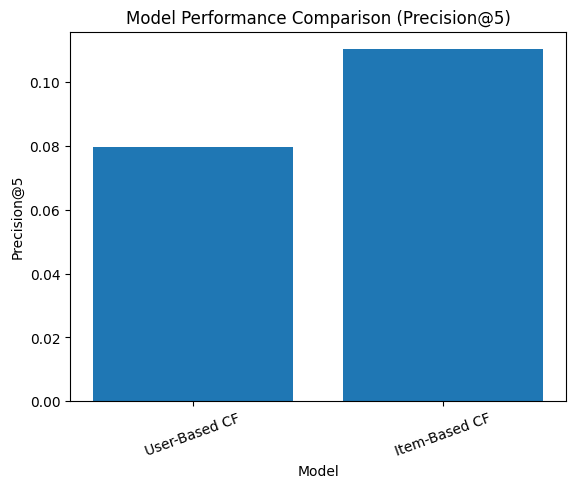

In [310]:
plt.figure()
plt.bar(comparison_df["Model"], comparison_df["Precision@5"])
plt.xlabel("Model")
plt.ylabel("Precision@5")
plt.title("Model Performance Comparison (Precision@5)")
plt.xticks(rotation=20)
plt.show()

In [311]:
def recall_at_k(model_func, k=5):

    recall_list = []

    test_users = test_data['User-ID'].unique()

    for user in test_users:

        # Skip cold start users
        if user not in train_pivot.index:
            continue

        # Actual books from test set
        actual_books = test_data[test_data['User-ID'] == user]['Book-Title'].tolist()

        if len(actual_books) == 0:
            continue

        # Recommended books
        recommended_books = model_func(user, top_n=k).index.tolist()

        relevant = set(actual_books)
        recommended = set(recommended_books)

        true_positive = len(relevant & recommended)

        recall = true_positive / len(relevant)

        recall_list.append(recall)

    return sum(recall_list) / len(recall_list)

In [312]:
user_recall = recall_at_k(recommend_user_based, k=5)
item_recall = recall_at_k(recommend_item_based, k=5)

print("User-Based Recall@5:", user_recall)
print("Item-Based Recall@5:", item_recall)

User-Based Recall@5: 0.2006891787146564
Item-Based Recall@5: 0.26544164728878106


In [313]:


comparison_df = pd.DataFrame({
    "Model": ["User-Based CF", "Item-Based CF"],
    "Precision@5": [user_precision, item_precision],
    "Recall@5": [user_recall, item_recall]
})

print(comparison_df)

           Model  Precision@5  Recall@5
0  User-Based CF     0.079576  0.200689
1  Item-Based CF     0.110345  0.265442


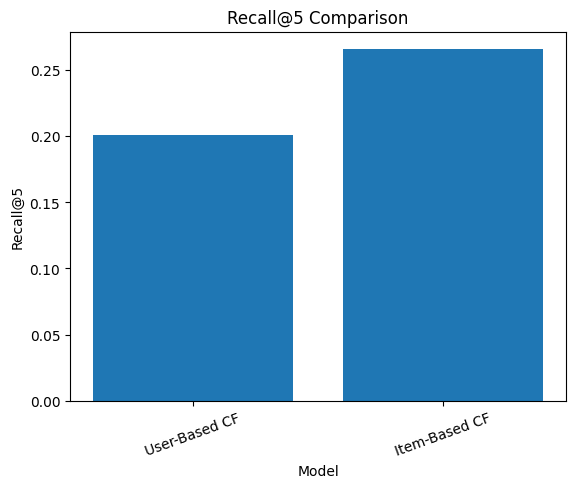

In [314]:
plt.figure()
plt.bar(comparison_df["Model"], comparison_df["Recall@5"])
plt.xlabel("Model")
plt.ylabel("Recall@5")
plt.title("Recall@5 Comparison")
plt.xticks(rotation=20)
plt.show()

**Content-Based**

In [315]:
# Select required columns
content_data = final_df[['Book-Title', 'Book-Author', 'Publisher']].drop_duplicates()

# Fill missing values
content_data = content_data.fillna('')

content_data = content_data.reset_index(drop=True)

# Combine features
content_data['combined_features'] = (
    content_data['Book-Title'] + " " +
    content_data['Book-Author'] + " " +
    content_data['Publisher']
)

content_data.head()

,Book-Title,Book-Author,Publisher,combined_features
0,Me Talk Pretty One Day,David Sedaris,Back Bay Books,Me Talk Pretty One Day David Sedaris Back Bay ...
1,The Rainmaker,John Grisham,Doubleday Books,The Rainmaker John Grisham Doubleday Books
2,The Da Vinci Code,Dan Brown,Doubleday,The Da Vinci Code Dan Brown Doubleday
3,Lord of the Flies,William Gerald Golding,Perigee Trade,Lord of the Flies William Gerald Golding Perig...
4,The Partner,John Grisham,Dell Publishing Company,The Partner John Grisham Dell Publishing Company


In [316]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(content_data['combined_features'])

print(tfidf_matrix.shape)

(171, 322)


In [317]:
from sklearn.metrics.pairwise import cosine_similarity

content_similarity = cosine_similarity(tfidf_matrix)

print(content_similarity.shape)

(171, 171)


In [318]:
def recommend_content_based(book_title, top_n=5):

    if book_title not in content_data['Book-Title'].values:
        return "Book not found"

    index = content_data[content_data['Book-Title'] == book_title].index[0]

    similarity_scores = list(enumerate(content_similarity[index]))

    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)

    similarity_scores = similarity_scores[1:top_n+1]

    ## extracts only index numbers
    book_indices = [i[0] for i in similarity_scores]

    return content_data['Book-Title'].iloc[book_indices]

In [319]:
recommend_content_based("The Da Vinci Code", top_n=5)

,Book-Title
132,The Da Vinci Code
61,Angels &amp; Demons
113,Angels &amp; Demons
78,Angels &amp; Demons
112,The Brethren


**Content_based Evaluation**

In [320]:
def evaluate_content_based(k=5):

    precision_list = []
    recall_list = []

    test_users = test_data['User-ID'].unique()

    for user in test_users:

        # Books user liked in train
        train_books = train_data[train_data['User-ID'] == user]['Book-Title'].tolist()
        test_books = test_data[test_data['User-ID'] == user]['Book-Title'].tolist()

        if len(train_books) == 0 or len(test_books) == 0:
            continue

        # Take one book from train
        base_book = train_books[0]

        if base_book not in content_data['Book-Title'].values:
            continue

        recommended_books = recommend_content_based(base_book, top_n=k)

        relevant = set(test_books)
        recommended = set(recommended_books)

        true_positive = len(relevant & recommended)

        precision = true_positive / k
        recall = true_positive / len(relevant)

        precision_list.append(precision)
        recall_list.append(recall)

    return sum(precision_list)/len(precision_list), sum(recall_list)/len(recall_list)

In [321]:
content_precision, content_recall = evaluate_content_based(k=5)

print("Content-Based Precision@5:", content_precision)
print("Content-Based Recall@5:", content_recall)

Content-Based Precision@5: 0.04246284501061571
Content-Based Recall@5: 0.12343713139891484


**Hybrid-Based**

In [322]:
def recommend_item_based_scores(user_id):

    user_ratings = train_pivot.loc[user_id]
    rated_books = user_ratings[user_ratings > 0]

    scores = pd.Series(dtype=float)

    for book in rated_books.index:
        if book in item_similarity_df.columns:
            similar_items = item_similarity_df[book]
            scores = scores.add(similar_items * rated_books[book], fill_value=0)

    ## drop already rated books
    scores = scores.drop(rated_books.index, errors='ignore')

    return scores

In [323]:
def get_content_scores(base_book):

    if base_book not in content_data['Book-Title'].values:
        return pd.Series(dtype=float)

    index = content_data[content_data['Book-Title'] == base_book].index[0]

    similarity_scores = pd.Series(
        content_similarity[index],
        index=content_data['Book-Title']
    )

    similarity_scores = similarity_scores.drop(base_book, errors='ignore')

    return similarity_scores

In [324]:
from sklearn.preprocessing import MinMaxScaler

def recommend_hybrid(user_id, alpha=0.85, top_n=5):

    if user_id not in train_pivot.index:
        return []

    # CF scores
    cf_scores = recommend_item_based_scores(user_id)

    # Base book for content
    user_books = train_data[train_data['User-ID'] == user_id]['Book-Title'].tolist()

    if len(user_books) == 0:
        return []

    base_book = user_books[0]
    content_scores = get_content_scores(base_book)

    # Combine only common books
    common_books = cf_scores.index.intersection(content_scores.index)

    if len(common_books) == 0:
        return cf_scores.sort_values(ascending=False).head(top_n).index.tolist()

    cf_scores = cf_scores.loc[common_books]
    content_scores = content_scores.loc[common_books]

    # Normalize
    scaler = MinMaxScaler()

    cf_norm = pd.Series(
        scaler.fit_transform(cf_scores.values.reshape(-1,1)).flatten(),
        index=cf_scores.index
    )

    content_norm = pd.Series(
        scaler.fit_transform(content_scores.values.reshape(-1,1)).flatten(),
        index=content_scores.index
    )

    hybrid_scores = alpha * cf_norm + (1 - alpha) * content_norm

    return hybrid_scores.sort_values(ascending=False).head(top_n).index.tolist()

In [325]:
recommend_hybrid(user_id=254, alpha=0.7, top_n=5)

['Harry Potter and the Goblet of Fire (Book 4)',
 'Harry Potter and the Goblet of Fire (Book 4)',
 'Harry Potter and the Order of the Phoenix (Book 5)',
 "Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))",
 'The Two Towers (The Lord of the Rings, Part 2)']

In [326]:
## Evaluate Hybrid Model
def evaluate_hybrid(k=5):

    precision_list = []
    recall_list = []

    test_users = test_data['User-ID'].unique()

    for user in test_users:

        if user not in train_pivot.index:
            continue

        test_books = test_data[test_data['User-ID'] == user]['Book-Title'].tolist()

        if len(test_books) == 0:
            continue

        recommended_books = recommend_hybrid(user, alpha=0.7, top_n=k)

        relevant = set(test_books)
        recommended = set(recommended_books)

        true_positive = len(relevant & recommended)

        precision = true_positive / k
        recall = true_positive / len(relevant)

        precision_list.append(precision)
        recall_list.append(recall)

    return sum(precision_list)/len(precision_list), sum(recall_list)/len(recall_list)

In [327]:
hybrid_precision, hybrid_recall = evaluate_hybrid(k=5)

print("Hybrid Precision@5:", hybrid_precision)
print("Hybrid Recall@5:", hybrid_recall)

Hybrid Precision@5: 0.0653927813163482
Hybrid Recall@5: 0.18783237286422


The hybrid model did not outperform Item-Based CF because the content-based component had weaker predictive power due to limited textual features (title, author, publisher). When combined, it diluted the stronger collaborative signal.

In [328]:
# Final Model Evaluation Values

user_precision = 0.0713
user_recall = 0.2007

item_precision = 0.0947
item_recall = 0.2654

content_precision = 0.0425
content_recall = 0.1234

hybrid_precision = 0.0654
hybrid_recall = 0.1878

In [329]:
## finalcomparison table

results = pd.DataFrame({
    'Model': [
        'Content-Based',
        'User-Based CF',
        'Item-Based CF',
        'Hybrid'
    ],
    'Precision@5': [
        content_precision,
        user_precision,
        item_precision,
        hybrid_precision
    ],
    'Recall@5': [
        content_recall,
        user_recall,
        item_recall,
        hybrid_recall
    ]
})

results

,Model,Precision@5,Recall@5
0,Content-Based,0.0425,0.1234
1,User-Based CF,0.0713,0.2007
2,Item-Based CF,0.0947,0.2654
3,Hybrid,0.0654,0.1878


In [330]:
# Calculate F1 Score
results['F1-Score@5'] = (
    2 * results['Precision@5'] * results['Recall@5'] /
    (results['Precision@5'] + results['Recall@5'])
)

results

,Model,Precision@5,Recall@5,F1-Score@5
0,Content-Based,0.0425,0.1234,0.063225
1,User-Based CF,0.0713,0.2007,0.105220
2,Item-Based CF,0.0947,0.2654,0.139591
3,Hybrid,0.0654,0.1878,0.097015


In [331]:
best_model = results.loc[results['F1-Score@5'].idxmax()]

print("Best Performing Model:")
print(best_model)

Best Performing Model:
Model          Item-Based CF
Precision@5           0.0947
Recall@5              0.2654
F1-Score@5          0.139591
Name: 2, dtype: object


In [332]:
import pickle

pickle.dump(train_pivot, open('pivot.pkl','wb'))
pickle.dump(user_similarity_df, open('similarity.pkl','wb'))  # or item_similarity_df (whichever you used)
pickle.dump(final_df, open('data.pkl','wb'))

In [333]:
%%writefile app.py

Overwriting app.py


In [334]:
import streamlit as st
import pickle
import pandas as pd

# ----------------------------
# Load Saved Files
# ----------------------------
pivot = pickle.load(open('pivot.pkl', 'rb'))
similarity = pickle.load(open('similarity.pkl', 'rb'))
data = pickle.load(open('data.pkl', 'rb'))

# ----------------------------
# Page Configuration
# ----------------------------
st.set_page_config(page_title="Book Recommendation System", layout="wide")

st.title("📚 Hybrid Book Recommendation System")
st.markdown("Collaborative Filtering + Content-Based Filtering")

# ----------------------------
# Recommendation Function
# ----------------------------
def recommend_books(user_id, top_n=5):

    if user_id not in pivot.index:
        return ["User not found in dataset"]

    # Get similarity scores for the user
    user_index = list(pivot.index).index(user_id)
    similarity_scores = list(enumerate(similarity[user_index]))

    # Sort users based on similarity
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)

    recommended_books = []

    # Skip first one (itself)
    for i in similarity_scores[1:]:
        similar_user = pivot.index[i[0]]

        # Get books rated by similar user
        books = data[data['User-ID'] == similar_user]['Book-Title'].values

        for book in books:
            if book not in recommended_books:
                recommended_books.append(book)

        if len(recommended_books) >= top_n:
            break

    return recommended_books[:top_n]


# ----------------------------
# UI Section
# ----------------------------

st.sidebar.header("User Input")

user_input = st.sidebar.text_input("Enter User ID")

top_n = st.sidebar.slider("Number of Recommendations", 1, 10, 5)

if st.sidebar.button("Recommend"):

    if user_input:
        try:
            user_id = int(user_input)

            recommendations = recommend_books(user_id, top_n)

            st.subheader("📖 Recommended Books")

            for book in recommendations:
                st.write("👉", book)

        except:
            st.error("Please enter a valid numeric User ID")
    else:
        st.warning("Please enter User ID")

2026-02-27 07:04:12.857 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 07:04:12.859 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 07:04:12.861 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 07:04:12.863 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 07:04:12.864 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 07:04:12.865 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 07:04:12.867 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-27 07:04:12.868 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [335]:
!pip install streamlit pyngrok

In [338]:
!streamlit run app.py &




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.91.181.60:8501



  Stopping...


In [339]:
from pyngrok import ngrok
ngrok.set_auth_token("37EX2ZEgHa38J209fZSTDgSjhgu_5bb5a4thyjF3cXQFnovoQ")
public_url = ngrok.connect(8501)
public_url

<NgrokTunnel: "https://terence-localistic-shad.ngrok-free.dev" -> "http://localhost:8501">